# Loading the dataset


In [1]:
import pandas as pd

datayo = pd.read_csv(r'C:\Users\Acer\OneDrive\Desktop\Job Hunting\Projects\Credit Risk\credit_risk_dataset.csv')

In [2]:
datayo.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
datayo.shape

(32581, 12)

In [4]:
datayo.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
datayo.loan_status.value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

In [6]:
datayo.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
datayo = datayo.rename(columns = {
    'person_age': 'age',
    'person_income': 'income',
    'person_home_ownership': 'home_ownership',
    'person_emp_length': 'emp_length',
    'loan_intent': 'loan_intent',
    'loan_grade': 'loan_grade',
    'loan_amnt': 'loan_amnt',
    'loan_int_rate': 'loan_int_rate',
    'loan_status': 'loan_status',
    'loan_percent_income': 'loan_percent_income',
    'cb_person_default_on_file': 'cb_person_default_on_file',
    'cb_person_cred_hist_length': 'cb_person_cred_hist_length'
    ''

})


In [8]:
datayo.columns

Index(['age', 'income', 'home_ownership', 'emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

##### Handeling the missing data

In [9]:
# Firstly filling the null values in the employment length column with 0
datayo['emp_length'] = datayo['emp_length'].fillna(0)

# Creating subset of rows with missing loan_int_rate
missng_loan_status_rows = datayo[datayo['loan_int_rate'].isnull()]

# Count defaults and non-defaults
print("Loan status counts:")
print(missng_loan_status_rows['loan_status'].value_counts())

# Percentage of loan status
print("\nPercentage of loan status:")
print(
    (missng_loan_status_rows['loan_status']
     .value_counts(normalize=True)
     .mul(100)
     .round(2)
     .astype(str) + '%')
)

Loan status counts:
loan_status
0    2472
1     644
Name: count, dtype: int64

Percentage of loan status:
loan_status
0    79.33%
1    20.67%
Name: proportion, dtype: object


In [10]:
# calculating the overall default rate 
overall_default_rate = datayo['loan_status'].mean() * 100
print("overall default rate:")
print(round(overall_default_rate, 2), "%")

overall default rate:
21.82 %


In [11]:
datayo = datayo.dropna(subset=['loan_int_rate'])
#dataset's shape after removing the missing values
print("dataset's shape after removing the missing values:")
print(datayo.shape)

# Checking the new default rate
new_default_rate = datayo['loan_status'].mean() * 100
print("new default rate after removal :")
print(round(new_default_rate, 2), "%")

dataset's shape after removing the missing values:
(29465, 12)
new default rate after removal :
21.94 %


In [12]:
datayo.describe()

,age,income,emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,29465.000000,2.946500e+04,29465.000000,29465.000000,29465.000000,29465.000000,29465.000000,29465.000000
mean,27.714712,6.602047e+04,4.654268,9584.744612,11.011695,0.219379,0.170110,5.788257
std,6.300193,6.190142e+04,4.171572,6316.272282,3.240459,0.413833,0.106879,4.031987
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.910000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


##### Handeling the missing values in the dataset

In [13]:
# firstly checking the shape and default rate before filtering
rows_before = datayo.shape[0]
default_rate_before = datayo['loan_status'].mean() * 100

print("rows before filtering:", rows_before)
print("default rate before filtering:", round(default_rate_before, 2), "%")


rows before filtering: 29465
default rate before filtering: 21.94 %


In [14]:
datayo.columns

Index(['age', 'income', 'home_ownership', 'emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [15]:
# applying the thresholds 
datayo_filtered = datayo[
    (datayo['age'] <= 90) &
    (datayo['emp_length'] <= 60) &
    (datayo['income'] <= 150000)
]

# checking the shape and default rate after filtering
rows_after = datayo_filtered.shape[0]
default_rate_after = datayo_filtered['loan_status'].mean() * 100
print("\nrows after filtering:", rows_after)
print("default rate after filtering:", round(default_rate_after, 2), "%")

# number and percentage of rows removed
rows_removed = rows_before - rows_after
percentage_removed = (rows_removed / rows_before) * 100
print("\nnumber of rows removed:", rows_removed)
print("percentage of rows removed:", round(percentage_removed, 2), "%")


rows after filtering: 28427
default rate after filtering: 22.37 %

number of rows removed: 1038
percentage of rows removed: 3.52 %


In [16]:
datayo_filtered.columns

Index(['age', 'income', 'home_ownership', 'emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [17]:
print(datayo_filtered['home_ownership'].value_counts())

print(datayo_filtered['loan_intent'].value_counts())

print(datayo_filtered['loan_grade'].value_counts())

print(datayo_filtered['cb_person_default_on_file'].value_counts())

home_ownership
RENT        14648
MORTGAGE    11417
OWN          2275
OTHER          87
Name: count, dtype: int64
loan_intent
EDUCATION            5673
MEDICAL              5306
VENTURE              4957
PERSONAL             4827
DEBTCONSOLIDATION    4529
HOMEIMPROVEMENT      3135
Name: count, dtype: int64
loan_grade
A    9494
B    9028
C    5629
D    3184
E     838
F     198
G      56
Name: count, dtype: int64
cb_person_default_on_file
N    23419
Y     5008
Name: count, dtype: int64


In [18]:
summary = pd.crosstab(
    datayo_filtered['cb_person_default_on_file'],
    datayo_filtered['loan_status'],
    margins=True
)

print(summary)

print("\nRow percentages:")
print(
    pd.crosstab(
        datayo_filtered['cb_person_default_on_file'],
        datayo_filtered['loan_status'],
        normalize='index'
    ).round(3) * 100
)

loan_status                    0     1    All
cb_person_default_on_file                    
N                          18996  4423  23419
Y                           3072  1936   5008
All                        22068  6359  28427

Row percentages:
loan_status                   0     1
cb_person_default_on_file            
N                          81.1  18.9
Y                          61.3  38.7


In [19]:
crosstab_pct = pd.crosstab(
    datayo_filtered['cb_person_default_on_file'],
    datayo_filtered['loan_status'],
    normalize='index'
) * 100

print(crosstab_pct.round(2))

loan_status                    0      1
cb_person_default_on_file              
N                          81.11  18.89
Y                          61.34  38.66


##### EDA 

##### Default rate by loan intent

loan_intent
VENTURE              15.27
EDUCATION            17.59
PERSONAL             20.65
HOMEIMPROVEMENT      27.08
MEDICAL              27.25
DEBTCONSOLIDATION    28.97
Name: loan_status, dtype: float64


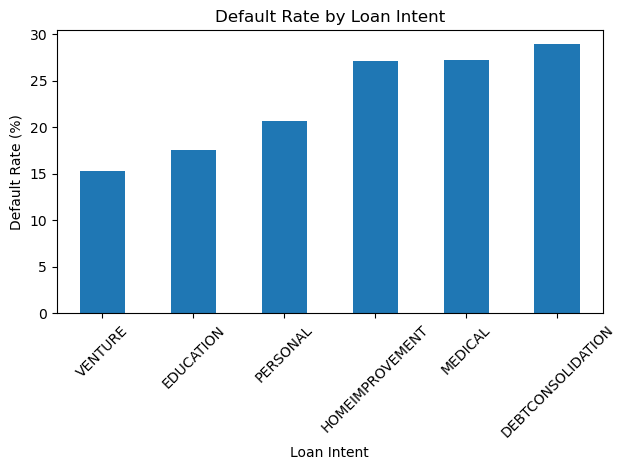

In [20]:
# Importing the necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
intent_default_rate = (
    datayo_filtered.groupby('loan_intent')['loan_status']
    .mean()
    .mul(100)
    .sort_values()
)
print(intent_default_rate.round(2))

# visualization 
intent_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


loan_grade
A    10.26
B    16.76
C    21.41
D    60.33
E    65.63
F    71.21
G    98.21
Name: loan_status, dtype: float64


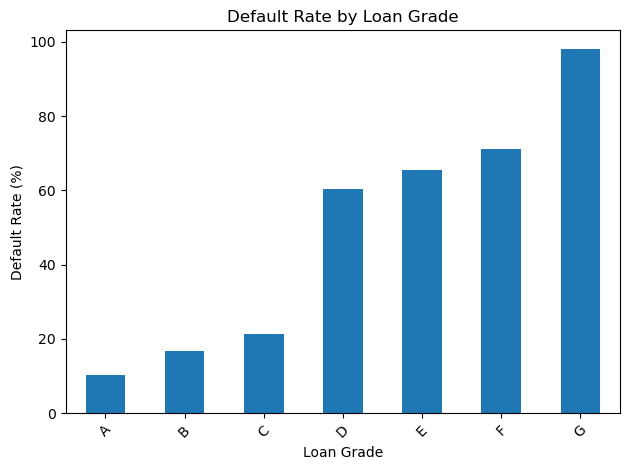

In [21]:
#Default rate by loan grade
# Importing the necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
intent_default_rate = (
    datayo_filtered.groupby('loan_grade')['loan_status']
    .mean()
    .mul(100)
    .sort_values()
)
print(intent_default_rate.round(2))

# visualization 
intent_default_rate.plot(kind='bar')

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


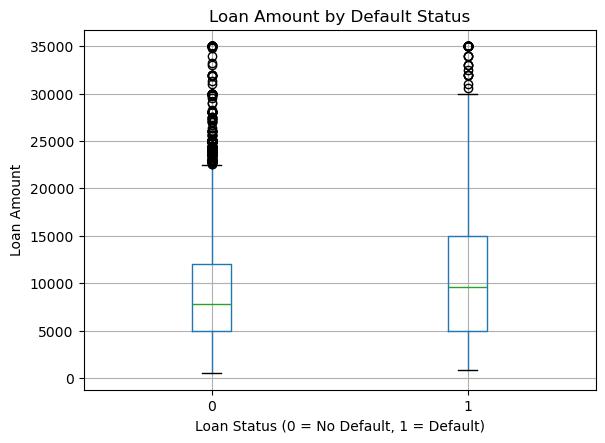

In [22]:
# distribution of loan amounts by default status
import matplotlib.pyplot as plt

datayo_filtered.boxplot(
    column='loan_amnt',
    by='loan_status'
)

plt.title('Loan Amount by Default Status')
plt.suptitle('')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Loan Amount')

plt.show()

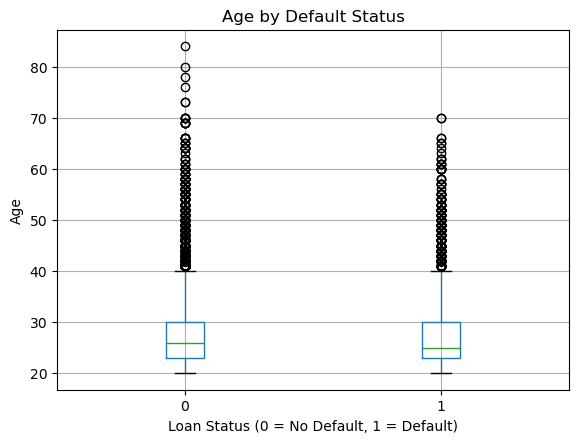

In [23]:
# Age distribution by default status
import matplotlib.pyplot as plt

datayo_filtered.boxplot(
    column='age',
    by='loan_status'
)

plt.title('Age by Default Status')
plt.suptitle('')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Age')

plt.show()

In [24]:
datayo_filtered.columns

Index(['age', 'income', 'home_ownership', 'emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

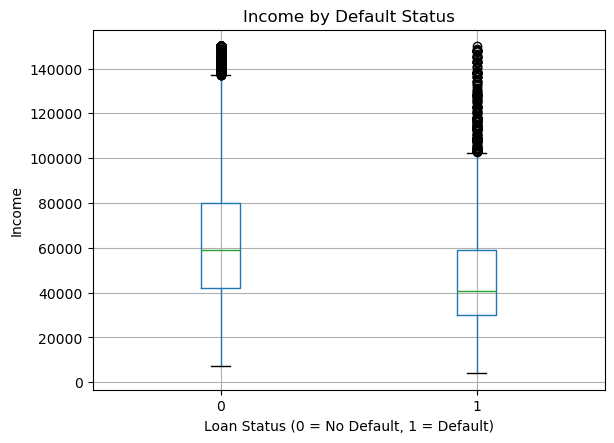

In [25]:
# income distribution by default status
import matplotlib.pyplot as plt

datayo_filtered.boxplot(
    column='income',
    by='loan_status'
)

plt.title('Income by Default Status')
plt.suptitle('')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Income')

plt.show()

In [26]:
datayo_filtered.columns

Index(['age', 'income', 'home_ownership', 'emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [27]:
datayo_filtered['income'].max()

150000

##### checking the Correlation between the predictors as well as the response variable

In [28]:
# creating a dummy variable for the categorical variables
encoded_data = pd.get_dummies(
    datayo_filtered,
    columns=['home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'],
    drop_first=True
)
print(encoded_data.shape)

(28427, 23)


In [29]:
# calculating the correlation matrix
correlation_matrix = encoded_data.corr()
loan_corr = correlation_matrix['loan_status'].sort_values(ascending=False)
print(loan_corr)

loan_status                    1.000000
loan_percent_income            0.379720
loan_int_rate                  0.336615
loan_grade_D                   0.323546
home_ownership_RENT            0.239398
loan_grade_E                   0.180936
cb_person_default_on_file_Y    0.180753
loan_amnt                      0.121149
loan_grade_F                   0.098161
loan_grade_G                   0.080861
loan_intent_MEDICAL            0.056129
loan_intent_HOMEIMPROVEMENT    0.039808
home_ownership_OTHER           0.009992
cb_person_cred_hist_length    -0.010194
loan_grade_C                  -0.011478
age                           -0.016345
loan_intent_PERSONAL          -0.018612
loan_intent_EDUCATION         -0.057244
loan_intent_VENTURE           -0.078281
emp_length                    -0.090727
loan_grade_B                  -0.091848
home_ownership_OWN            -0.106059
income                        -0.249268
Name: loan_status, dtype: float64


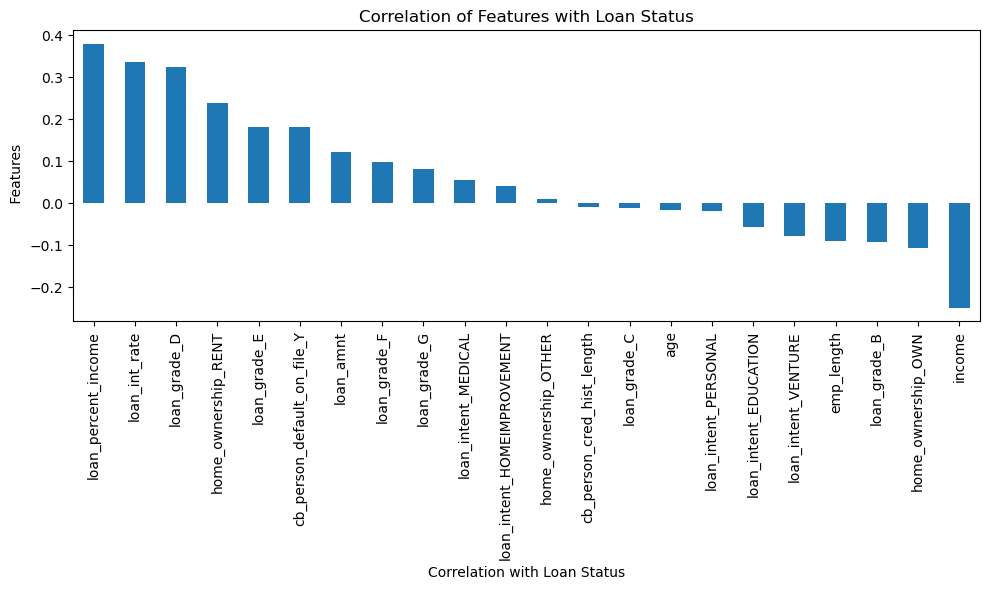

In [30]:
#plotting the corrrelation matrix
#dropping the response vaiable form the graph
loan_corr_no_response = loan_corr.drop('loan_status')
plt.figure(figsize=(10, 6))
loan_corr_no_response.plot(kind='bar')
plt.title('Correlation of Features with Loan Status')
plt.xlabel('Correlation with Loan Status')
plt.ylabel(' Features')
plt.tight_layout()
plt.show()

##### Running the model 

In [31]:
#### Defining the target variable and also defining the feature mix
y = encoded_data['loan_status']


In [32]:
x = encoded_data.drop('loan_status', axis=1)
print ("x shape",x.shape)
print ("y shape",y.shape)

x shape (28427, 22)
y shape (28427,)


In [33]:
### performing an 80/20 train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

#verifying the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("/nTraining default rate:")
print(round(y_train.mean() * 100, 2), "%")
print("Testing default rate:")
print(round(y_test.mean() * 100, 2), "%")

X_train shape: (22741, 22)
X_test shape: (5686, 22)
/nTraining default rate:
22.37 %
Testing default rate:
22.37 %


In [34]:
# Verifying the split
x.columns.tolist()

['age',
 'income',
 'emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'loan_grade_B',
 'loan_grade_C',
 'loan_grade_D',
 'loan_grade_E',
 'loan_grade_F',
 'loan_grade_G',
 'cb_person_default_on_file_Y']

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

print(
    "ROC AUC:",
    round(
        roc_auc_score(
            y_test,
            lr_model.predict_proba(X_test_scaled)[:, 1]
        ),
        3
    )
)

              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4414
           1       0.77      0.55      0.64      1272

    accuracy                           0.86      5686
   macro avg       0.83      0.75      0.78      5686
weighted avg       0.86      0.86      0.85      5686

ROC AUC: 0.866


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", round(roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]), 3))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4414
           1       0.77      0.55      0.64      1272

    accuracy                           0.86      5686
   macro avg       0.83      0.75      0.78      5686
weighted avg       0.86      0.86      0.85      5686

ROC AUC: 0.866


In [43]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ------------------------
# Random Forest
# ------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print(
    "ROC AUC:",
    round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]), 3)
)

# ------------------------
# XGBoost
# ------------------------
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBOOST")
print(classification_report(y_test, y_pred_xgb))
print(
    "ROC AUC:",
    round(roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]), 3)
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4414
           1       0.96      0.73      0.83      1272

    accuracy                           0.93      5686
   macro avg       0.94      0.86      0.89      5686
weighted avg       0.93      0.93      0.93      5686

ROC AUC: 0.934

XGBOOST
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4414
           1       0.95      0.74      0.83      1272

    accuracy                           0.93      5686
   macro avg       0.94      0.86      0.89      5686
weighted avg       0.93      0.93      0.93      5686

ROC AUC: 0.95


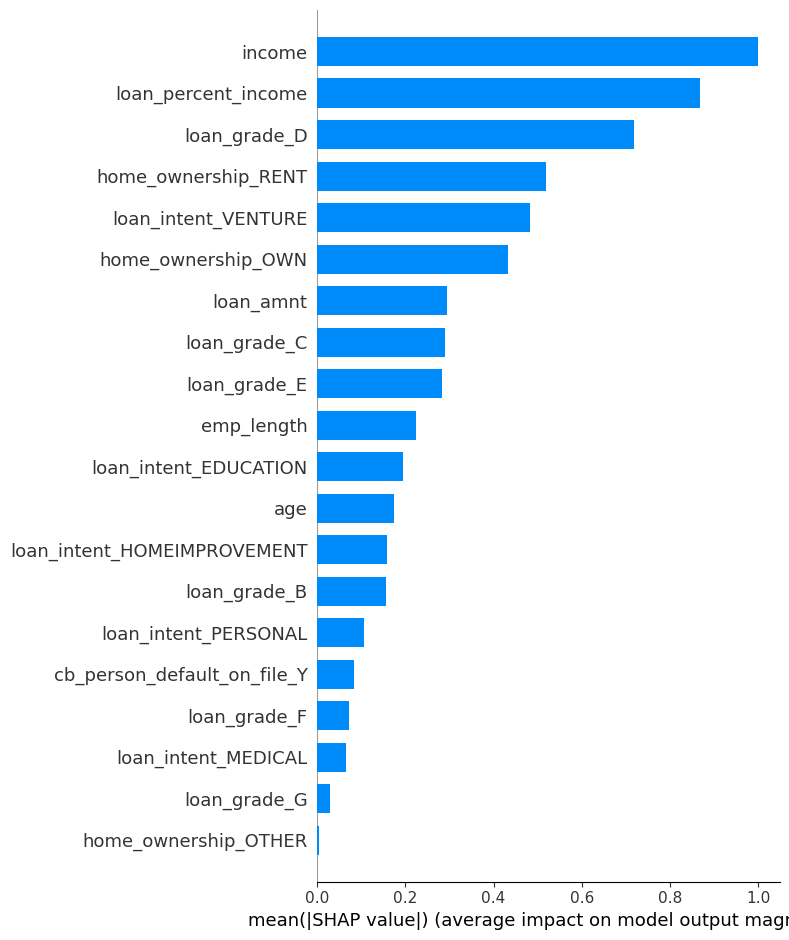

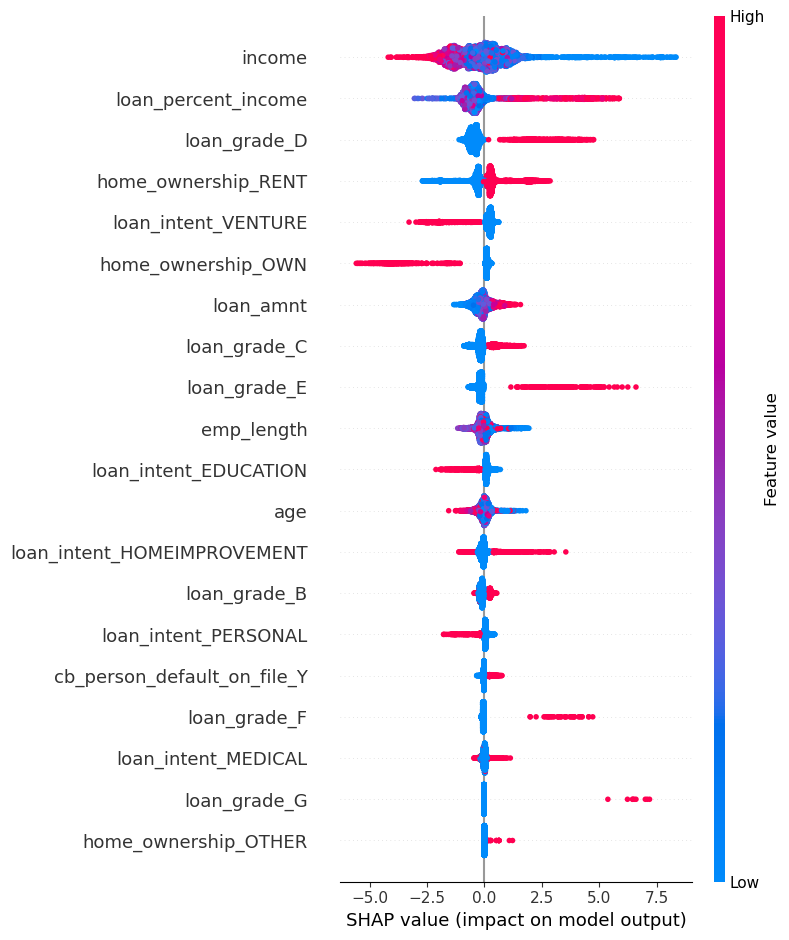

In [44]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot (feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Full SHAP distribution plot
shap.summary_plot(shap_values, X_test)

# Saving the cleaned Dataset

In [45]:
datayo_filtered.to_csv('Credit_risk_clean.csv', index=False)

In [46]:
datayo_filtered.isnull().sum()

age                           0
income                        0
home_ownership                0
emp_length                    0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64